# Task 2 — Network Construction

Build a drug-disease network from DrugBank data with four entity types: Drugs, Protein Targets, Genes, and Diseases. Includes three edge types: drug-target, gene-disease, and drug-disease relationships as specified in the assignment.

## 1. Initialize Project Environment

In [8]:
"""Setup and imports for Lab 9 Task 2 - Network Construction."""
import logging
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Python {sys.version}")
print(f"networkx {nx.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")

Python 3.12.3 (main, Jan  8 2026, 11:30:50) [GCC 13.3.0]
networkx 3.3
matplotlib 3.9.4


## 2. Define Configuration Parameters

In [9]:
@dataclass
class Task2Config:
    """Configuration for network construction."""

    handle: str = "AndreiCod"
    export_dir: Path = Path("./artifacts")
    drugs_file: str = "task1_drugs.csv"
    targets_file: str = "task1_drug_targets.csv"
    diseases_file: str = "task1_drug_diseases.csv"
    gene_diseases_file: str = (
        "task1_gene_diseases.csv"  # NEW: gene-disease associations
    )

    def __post_init__(self):
        self.export_dir.mkdir(parents=True, exist_ok=True)

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = Task2Config()
CONFIG.describe()

{'handle': 'AndreiCod',
 'export_dir': 'artifacts',
 'drugs_file': 'task1_drugs.csv',
 'targets_file': 'task1_drug_targets.csv',
 'diseases_file': 'task1_drug_diseases.csv',
 'gene_diseases_file': 'task1_gene_diseases.csv'}

## 3. Implement Core Functionality

In [10]:
def load_task1_data(export_dir: Path, config: Task2Config):
    """Load prepared data from Task 1."""
    drugs_df = pd.read_csv(export_dir / config.drugs_file)
    targets_df = pd.read_csv(export_dir / config.targets_file)
    diseases_df = pd.read_csv(export_dir / config.diseases_file)
    gene_diseases_df = pd.read_csv(export_dir / config.gene_diseases_file)  # NEW

    logging.info(
        "Loaded %d drugs, %d drug-target, %d drug-disease, %d gene-disease edges",
        len(drugs_df),
        len(targets_df),
        len(diseases_df),
        len(gene_diseases_df),
    )
    return drugs_df, targets_df, diseases_df, gene_diseases_df


# Load Task 1 output
drugs_df, targets_df, diseases_df, gene_diseases_df = load_task1_data(
    CONFIG.export_dir, CONFIG
)
print(f"[OK] Loaded data from Task 1")
print(f"    - {len(drugs_df)} drugs")
print(f"    - {len(targets_df)} drug-target edges")
print(f"    - {len(diseases_df)} drug-disease edges")
print(f"    - {len(gene_diseases_df)} gene-disease edges")

22:30:17 | INFO | Loaded 16575 drugs, 14802 drug-target, 5983 drug-disease, 14571 gene-disease edges


[OK] Loaded data from Task 1
    - 16575 drugs
    - 14802 drug-target edges
    - 5983 drug-disease edges
    - 14571 gene-disease edges


In [11]:
def build_drug_disease_network(
    drugs_df: pd.DataFrame,
    targets_df: pd.DataFrame,
    diseases_df: pd.DataFrame,
    gene_diseases_df: pd.DataFrame,
) -> nx.Graph:
    """
    Build drug-disease network with four node types as per assignment:
    - Drug nodes
    - Target nodes (protein targets)
    - Gene nodes (using gene_name from targets, linked to diseases)
    - Disease nodes

    Edges (3 types as required):
    - Drug → Target (drug-target interaction)
    - Gene → Disease (gene-disease association) - ADDED per Issue #1
    - Drug → Disease (direct indication, optional visualization)
    """
    G = nx.Graph()

    # Add drug nodes
    for _, row in drugs_df.iterrows():
        G.add_node(
            row["drug_name"],
            node_type="Drug",
            drug_id=row["drug_id"],
            drug_type=row["drug_type"],
        )

    # Track unique genes for gene nodes
    gene_info = {}

    # Add target nodes and drug-target edges
    for _, row in targets_df.iterrows():
        target_name = row["target_name"]
        gene_name = (
            row["gene_name"] if pd.notna(row["gene_name"]) and row["gene_name"] else ""
        )

        # Add target node (protein) if not exists
        if target_name not in G:
            G.add_node(
                target_name,
                node_type="Target",
                gene_name=gene_name,
                uniprot_id=row["uniprot_id"],
            )

        # Track gene info for gene nodes
        if gene_name and gene_name not in gene_info:
            gene_info[gene_name] = {
                "uniprot_id": row["uniprot_id"],
                "target_name": target_name,
            }

        # Add drug-target edge
        if row["drug_name"] in G:
            G.add_edge(
                row["drug_name"],
                target_name,
                edge_type="drug-target",
                action=row["actions"],
            )

    # Add gene nodes (separate from protein targets for clarity)
    for gene_name, info in gene_info.items():
        gene_node_id = f"Gene:{gene_name}"
        if gene_node_id not in G:
            G.add_node(
                gene_node_id,
                node_type="Gene",
                gene_name=gene_name,
                uniprot_id=info["uniprot_id"],
            )

        # Link gene to its protein target (protein-gene relationship)
        if info["target_name"] in G:
            G.add_edge(
                info["target_name"],
                gene_node_id,
                edge_type="protein-gene",
            )

    # Add disease nodes and gene-disease edges (Issue #1 FIX)
    disease_nodes_added = set()
    for _, row in gene_diseases_df.iterrows():
        disease = row["disease"]
        gene_name = row["gene_name"]
        gene_node_id = f"Gene:{gene_name}"

        # Add disease node if not exists
        if disease not in G:
            G.add_node(disease, node_type="Disease")
            disease_nodes_added.add(disease)

        # Add gene-disease edge (KEY RELATIONSHIP per assignment)
        if gene_node_id in G:
            G.add_edge(
                gene_node_id,
                disease,
                edge_type="gene-disease",
                relationship=row.get("relationship", "associated_with"),
            )

    # Also add drug-disease direct edges (for completeness)
    for _, row in diseases_df.iterrows():
        disease = row["disease"]
        if disease not in G:
            G.add_node(disease, node_type="Disease")

        if row["drug_name"] in G:
            G.add_edge(
                row["drug_name"],
                disease,
                edge_type="drug-disease",
            )

    # Log statistics
    drug_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "Drug"]
    target_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "Target"]
    gene_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "Gene"]
    disease_nodes = [
        n for n, d in G.nodes(data=True) if d.get("node_type") == "Disease"
    ]

    # Count edge types
    edge_counts = {}
    for u, v, d in G.edges(data=True):
        edge_type = d.get("edge_type", "unknown")
        edge_counts[edge_type] = edge_counts.get(edge_type, 0) + 1

    logging.info(
        "Built network: %d nodes (%d drugs, %d targets, %d genes, %d diseases), %d edges",
        G.number_of_nodes(),
        len(drug_nodes),
        len(target_nodes),
        len(gene_nodes),
        len(disease_nodes),
        G.number_of_edges(),
    )
    logging.info("Edge types: %s", edge_counts)

    return G


# Build the network
G = build_drug_disease_network(drugs_df, targets_df, diseases_df, gene_diseases_df)
print(f"[OK] Network nodes: {G.number_of_nodes()}")
print(f"[OK] Network edges: {G.number_of_edges()}")

# Show node type breakdown
for node_type in ["Drug", "Target", "Gene", "Disease"]:
    count = len([n for n, d in G.nodes(data=True) if d.get("node_type") == node_type])
    print(f"    - {node_type} nodes: {count}")

# Show edge type breakdown
edge_counts = {}
for u, v, d in G.edges(data=True):
    edge_type = d.get("edge_type", "unknown")
    edge_counts[edge_type] = edge_counts.get(edge_type, 0) + 1
print(f"\nEdge type breakdown:")
for edge_type, count in sorted(edge_counts.items()):
    print(f"    - {edge_type}: {count}")

22:30:19 | INFO | Built network: 26616 nodes (16575 drugs, 2887 targets, 2794 genes, 4360 diseases), 38150 edges
22:30:19 | INFO | Edge types: {'drug-target': 14802, 'drug-disease': 5983, 'protein-gene': 2794, 'gene-disease': 14571}


[OK] Network nodes: 26616
[OK] Network edges: 38150
    - Drug nodes: 16575
    - Target nodes: 2887
    - Gene nodes: 2794
    - Disease nodes: 4360

Edge type breakdown:
    - drug-disease: 5983
    - drug-target: 14802
    - gene-disease: 14571
    - protein-gene: 2794


## 4. Validate with Unit Tests

In [12]:
# Validate network structure
assert G.number_of_nodes() > 0, "Empty network"
assert G.number_of_edges() > 0, "No edges in network"
assert all("node_type" in G.nodes[n] for n in G.nodes()), "Missing node_type attribute"

# Check node types (now 4 types as per assignment)
drug_nodes = [n for n, attr in G.nodes(data=True) if attr["node_type"] == "Drug"]
target_nodes = [n for n, attr in G.nodes(data=True) if attr["node_type"] == "Target"]
gene_nodes = [n for n, attr in G.nodes(data=True) if attr["node_type"] == "Gene"]
disease_nodes = [n for n, attr in G.nodes(data=True) if attr["node_type"] == "Disease"]

assert len(drug_nodes) > 0, "No drug nodes found"
assert len(target_nodes) > 0, "No target nodes found"
assert len(gene_nodes) > 0, "No gene nodes found"  # NEW validation
assert len(disease_nodes) > 0, "No disease nodes found"

# Validate edge types exist (Issue #1: gene-disease edges must exist)
edge_types = set(d.get("edge_type") for u, v, d in G.edges(data=True))
assert "drug-target" in edge_types, "Missing drug-target edges"
assert "gene-disease" in edge_types, "Missing gene-disease edges (Issue #1)"

print(f"[OK] Validation passed:")
print(f"    - {len(drug_nodes)} drugs")
print(f"    - {len(target_nodes)} targets/proteins")
print(f"    - {len(gene_nodes)} genes")
print(f"    - {len(disease_nodes)} diseases")
print(f"    - Edge types present: {edge_types}")

[OK] Validation passed:
    - 16575 drugs
    - 2887 targets/proteins
    - 2794 genes
    - 4360 diseases
    - Edge types present: {'drug-target', 'gene-disease', 'drug-disease', 'protein-gene'}


22:30:19 | INFO | Visualizing subgraph with 250 highest-degree nodes
22:30:20 | INFO | Network visualization saved to: artifacts/task2_network_viz.png


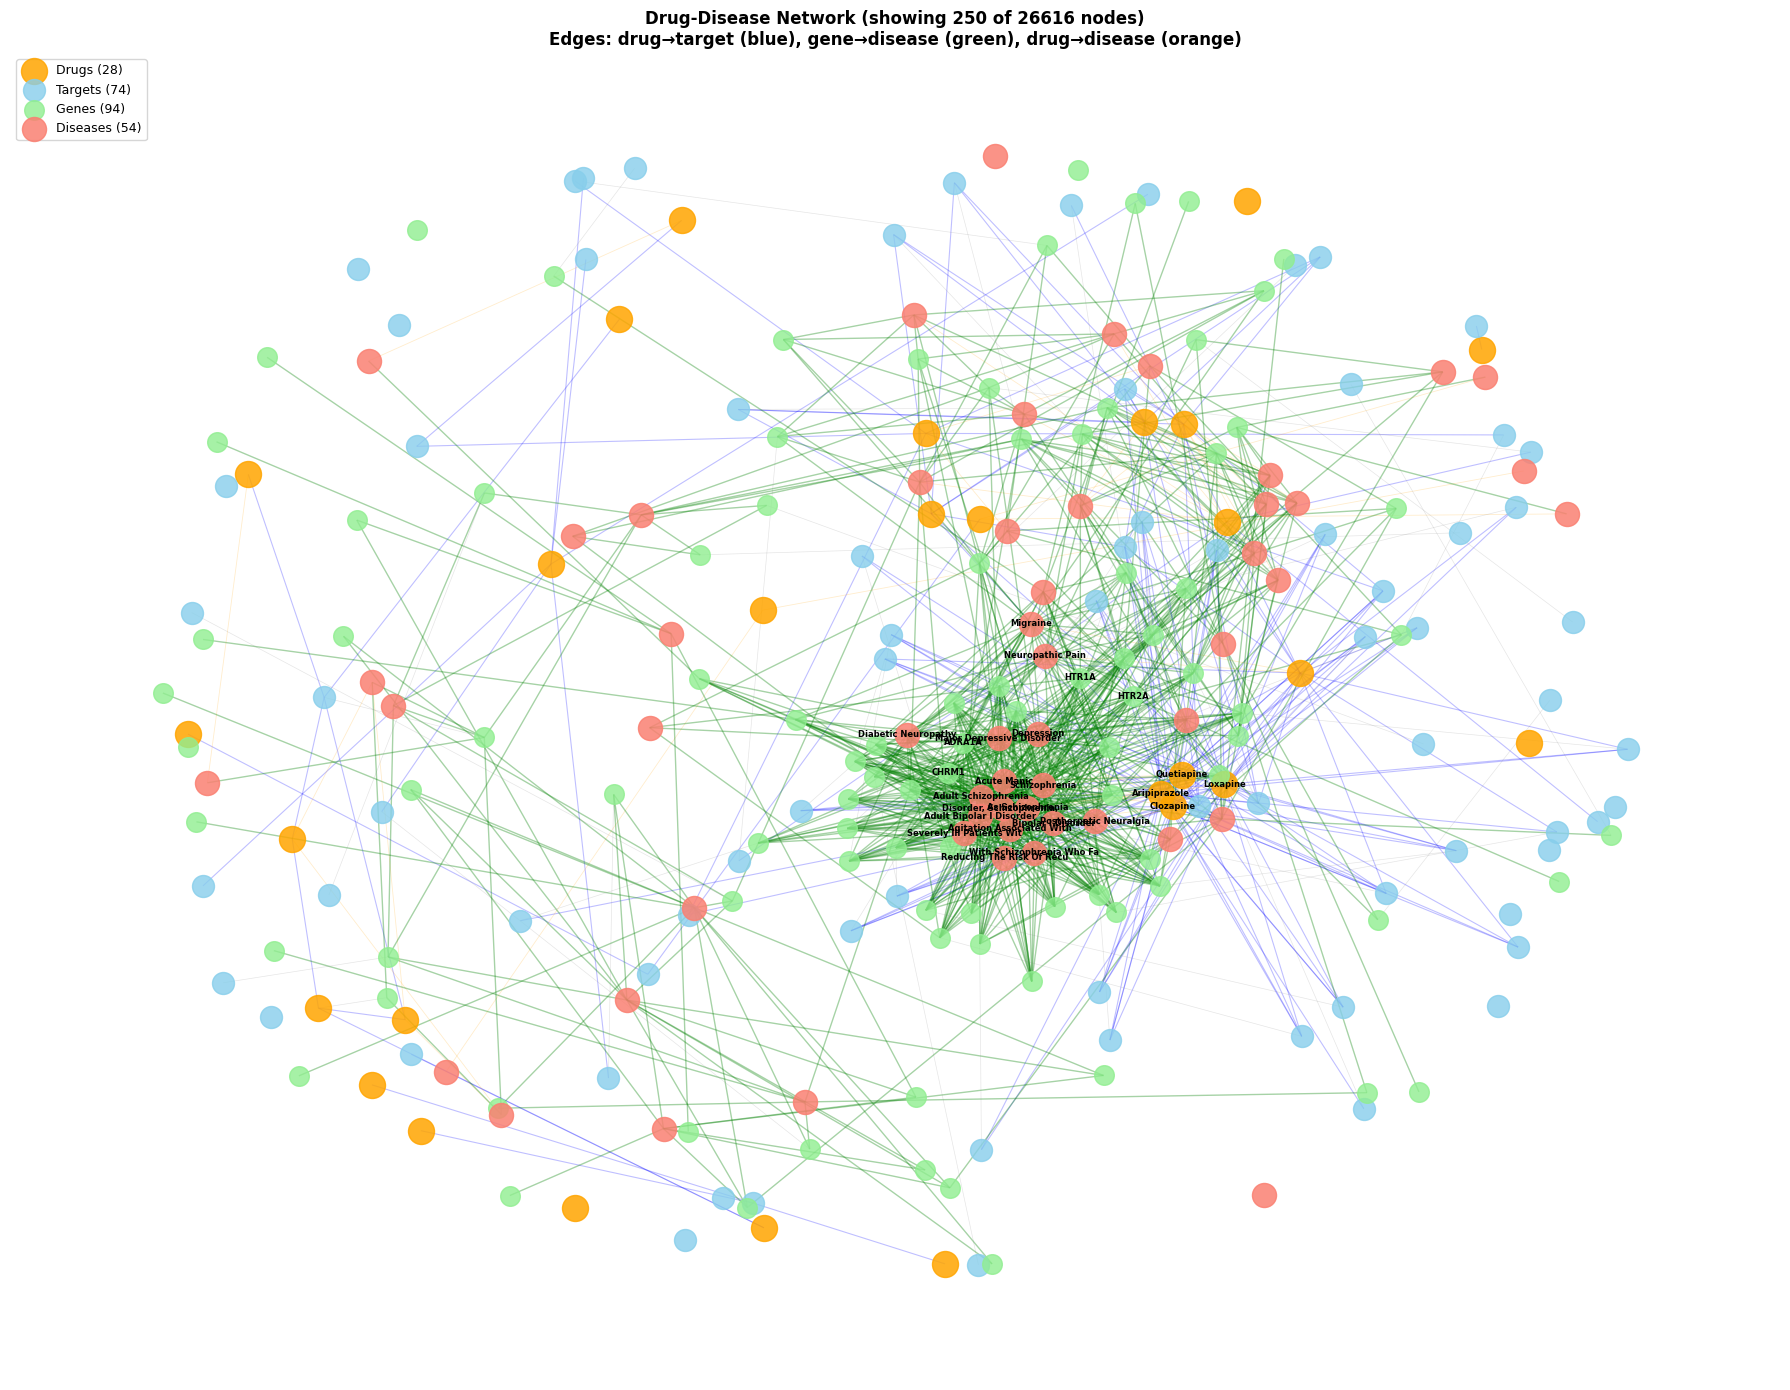

In [13]:
def visualize_network(G: nx.Graph, output_path: Path, max_nodes: int = 250):
    """
    Create network visualization with node type coloring.
    Shows 4 node types: Drug (orange), Target (blue), Gene (green), Disease (red).
    For large networks, shows a subgraph of highest-degree nodes.
    """
    # For large networks, extract a subgraph
    if G.number_of_nodes() > max_nodes:
        degree_dict = dict(G.degree())
        top_nodes = sorted(
            degree_dict.keys(), key=lambda x: degree_dict[x], reverse=True
        )[:max_nodes]
        G_sub = G.subgraph(top_nodes).copy()
        logging.info("Visualizing subgraph with %d highest-degree nodes", max_nodes)
    else:
        G_sub = G

    plt.figure(figsize=(18, 14))

    # Separate nodes by type (now 4 types)
    drug_nodes = [
        n for n, attr in G_sub.nodes(data=True) if attr.get("node_type") == "Drug"
    ]
    target_nodes = [
        n for n, attr in G_sub.nodes(data=True) if attr.get("node_type") == "Target"
    ]
    gene_nodes = [
        n for n, attr in G_sub.nodes(data=True) if attr.get("node_type") == "Gene"
    ]
    disease_nodes = [
        n for n, attr in G_sub.nodes(data=True) if attr.get("node_type") == "Disease"
    ]

    # Layout
    pos = nx.spring_layout(G_sub, seed=42, k=0.6, iterations=60)

    # Draw nodes by type with distinct colors
    nx.draw_networkx_nodes(
        G_sub,
        pos,
        nodelist=drug_nodes,
        node_color="orange",
        node_size=350,
        label=f"Drugs ({len(drug_nodes)})",
        alpha=0.85,
    )
    nx.draw_networkx_nodes(
        G_sub,
        pos,
        nodelist=target_nodes,
        node_color="skyblue",
        node_size=250,
        label=f"Targets ({len(target_nodes)})",
        alpha=0.8,
    )
    nx.draw_networkx_nodes(
        G_sub,
        pos,
        nodelist=gene_nodes,
        node_color="lightgreen",
        node_size=200,
        label=f"Genes ({len(gene_nodes)})",
        alpha=0.8,
    )
    nx.draw_networkx_nodes(
        G_sub,
        pos,
        nodelist=disease_nodes,
        node_color="salmon",
        node_size=300,
        label=f"Diseases ({len(disease_nodes)})",
        alpha=0.85,
    )

    # Draw edges with different colors by type
    drug_target_edges = [
        (u, v)
        for u, v, d in G_sub.edges(data=True)
        if d.get("edge_type") == "drug-target"
    ]
    drug_disease_edges = [
        (u, v)
        for u, v, d in G_sub.edges(data=True)
        if d.get("edge_type") == "drug-disease"
    ]
    gene_disease_edges = [
        (u, v)
        for u, v, d in G_sub.edges(data=True)
        if d.get("edge_type") == "gene-disease"
    ]
    protein_gene_edges = [
        (u, v)
        for u, v, d in G_sub.edges(data=True)
        if d.get("edge_type") == "protein-gene"
    ]

    nx.draw_networkx_edges(
        G_sub, pos, edgelist=drug_target_edges, alpha=0.25, width=0.8, edge_color="blue"
    )
    nx.draw_networkx_edges(
        G_sub,
        pos,
        edgelist=drug_disease_edges,
        alpha=0.2,
        width=0.6,
        edge_color="orange",
    )
    nx.draw_networkx_edges(
        G_sub,
        pos,
        edgelist=gene_disease_edges,
        alpha=0.35,
        width=1.0,
        edge_color="green",
    )
    nx.draw_networkx_edges(
        G_sub, pos, edgelist=protein_gene_edges, alpha=0.2, width=0.5, edge_color="gray"
    )

    # Label top nodes
    top_degree = sorted(dict(G_sub.degree()).items(), key=lambda x: x[1], reverse=True)[
        :25
    ]
    labels = {n: n[:25].replace("Gene:", "").replace("_", " ") for n, _ in top_degree}
    nx.draw_networkx_labels(G_sub, pos, labels, font_size=6, font_weight="bold")

    plt.title(
        f"Drug-Disease Network (showing {G_sub.number_of_nodes()} of {G.number_of_nodes()} nodes)\n"
        f"Edges: drug→target (blue), gene→disease (green), drug→disease (orange)",
        fontsize=12,
        fontweight="bold",
    )
    plt.legend(scatterpoints=1, fontsize=9, loc="upper left")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    logging.info("Network visualization saved to: %s", output_path)
    plt.show()


# Visualize
viz_file = CONFIG.export_dir / "task2_network_viz.png"
visualize_network(G, viz_file)

## 5. Export Results

In [14]:
# Export network in GML format
EXPORT_DIR = CONFIG.export_dir
network_file = EXPORT_DIR / "task2_network.gml"
nx.write_gml(G, network_file)

# Export network summary statistics (updated for 4 node types and all edge types)
summary = {
    "total_nodes": G.number_of_nodes(),
    "total_edges": G.number_of_edges(),
    "drug_nodes": len(
        [n for n, d in G.nodes(data=True) if d.get("node_type") == "Drug"]
    ),
    "target_nodes": len(
        [n for n, d in G.nodes(data=True) if d.get("node_type") == "Target"]
    ),
    "gene_nodes": len(
        [n for n, d in G.nodes(data=True) if d.get("node_type") == "Gene"]
    ),
    "disease_nodes": len(
        [n for n, d in G.nodes(data=True) if d.get("node_type") == "Disease"]
    ),
    "drug_target_edges": len(
        [e for e in G.edges(data=True) if e[2].get("edge_type") == "drug-target"]
    ),
    "gene_disease_edges": len(
        [e for e in G.edges(data=True) if e[2].get("edge_type") == "gene-disease"]
    ),
    "drug_disease_edges": len(
        [e for e in G.edges(data=True) if e[2].get("edge_type") == "drug-disease"]
    ),
    "protein_gene_edges": len(
        [e for e in G.edges(data=True) if e[2].get("edge_type") == "protein-gene"]
    ),
}

summary_df = pd.DataFrame([summary])
summary_file = EXPORT_DIR / "task2_network_summary.csv"
summary_df.to_csv(summary_file, index=False)

print(f"[OK] Network saved to: {network_file.resolve()}")
print(f"[OK] Summary saved to: {summary_file.resolve()}")
print(f"[OK] Visualization saved to: {viz_file.resolve()}")
print("\n=== Network Summary ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

[OK] Network saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/09_repurposing/assignments/artifacts/task2_network.gml
[OK] Summary saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/09_repurposing/assignments/artifacts/task2_network_summary.csv
[OK] Visualization saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/09_repurposing/assignments/artifacts/task2_network_viz.png

=== Network Summary ===
  total_nodes: 26616
  total_edges: 38150
  drug_nodes: 16575
  target_nodes: 2887
  gene_nodes: 2794
  disease_nodes: 4360
  drug_target_edges: 14802
  gene_disease_edges: 14571
  drug_disease_edges: 5983
  protein_gene_edges: 2794
